## Mount Google Drive

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Move to MyDrive

In [32]:
import os

os.chdir('/content/drive/MyDrive')
print("Current working directory:", os.getcwd())

Current working directory: /content/drive/MyDrive


## Create Project Folder Structure

In [33]:
import os

project_root = "rocket_telemetry_project"

folders = [
    "data",
    "src",
    "models",
    "results/plots",
    "results/metrics",
    "notebooks"
]

os.makedirs(project_root, exist_ok=True)

for folder in folders:
    os.makedirs(os.path.join(project_root, folder), exist_ok=True)

print("Project structure created successfully")

Project structure created successfully


## Move Into Project Folder

In [34]:
os.chdir("rocket_telemetry_project")
print("Current working directory:", os.getcwd())

Current working directory: /content/drive/MyDrive/rocket_telemetry_project


## Install KaggleHub

In [35]:
!pip install kagglehub

## Download NASA Dataset

In [36]:
import kagglehub

dataset_path = kagglehub.dataset_download("patrickfleith/nasa-anomaly-detection-dataset-smap-msl")

print("Dataset downloaded to:")
print(dataset_path)

Using Colab cache for faster access to the 'nasa-anomaly-detection-dataset-smap-msl' dataset.
Dataset downloaded to:
/kaggle/input/nasa-anomaly-detection-dataset-smap-msl


## Explore Dataset Structure

In [38]:
import os

print("LEVEL 1:")
print(os.listdir(dataset_path))

level1 = os.listdir(dataset_path)[1]
path1 = os.path.join(dataset_path, level1)

print("\nLEVEL 2:")
print(os.listdir(path1))

level2 = os.listdir(path1)[0]
path2 = os.path.join(path1, level2)

print("\nLEVEL 3:")
print(os.listdir(path2))

print("\nFULL PATH USED:")
print(path2)

LEVEL 1:
['labeled_anomalies.csv', 'data']

LEVEL 2:
['data']

LEVEL 3:
['2018-05-19_15.00.10', 'test', 'train']

FULL PATH USED:
/kaggle/input/nasa-anomaly-detection-dataset-smap-msl/data/data


## Copy train/test into project data folder

In [39]:
import shutil

train_src = os.path.join(path2, "train")
test_src = os.path.join(path2, "test")

train_dst = "data/train"
test_dst = "data/test"

shutil.copytree(train_src, train_dst, dirs_exist_ok=True)
shutil.copytree(test_src, test_dst, dirs_exist_ok=True)

print("Train and Test folders copied successfully")

Train and Test folders copied successfully


## Copy labeled_anomalies.csv

In [40]:
import os
import shutil

# Search for labeled_anomalies.csv anywhere in dataset
labels_src = None

for root, dirs, files in os.walk(dataset_path):
    if "labeled_anomalies.csv" in files:
        labels_src = os.path.join(root, "labeled_anomalies.csv")
        break

print("Found labels file at:", labels_src)

labels_dst = "data/labeled_anomalies.csv"

shutil.copy(labels_src, labels_dst)

print("Labels file copied successfully")

Found labels file at: /kaggle/input/nasa-anomaly-detection-dataset-smap-msl/labeled_anomalies.csv
Labels file copied successfully


## Verify Channel Counts

In [41]:
train_files = [f for f in os.listdir("data/train") if f.endswith(".npy")]
test_files = [f for f in os.listdir("data/test") if f.endswith(".npy")]

print("Train channels:", len(train_files))
print("Test channels:", len(test_files))

Train channels: 82
Test channels: 82


## Imports for Functions

In [42]:
import numpy as np
import pandas as pd
import ast
import os

## Function: load_channel

In [43]:
def load_channel(channel_id, data_dir="data"):

    train_path = os.path.join(data_dir, "train", f"{channel_id}.npy")
    test_path = os.path.join(data_dir, "test", f"{channel_id}.npy")

    # assert file exists
    assert os.path.exists(train_path), f"Train file missing: {train_path}"
    assert os.path.exists(test_path), f"Test file missing: {test_path}"

    train = np.load(train_path)
    test = np.load(test_path)

    # assert arrays are 2D
    assert train.ndim == 2, "Train array must be 2D"
    assert test.ndim == 2, "Test array must be 2D"

    # assert no NaN values
    assert not np.isnan(train).any(), "Train contains NaN values"
    assert not np.isnan(test).any(), "Test contains NaN values"

    print(f"[{channel_id}] Train: {train.shape} | Test: {test.shape}")

    return train, test

## Function: load_anomaly_labels

In [44]:
def load_anomaly_labels(channel_id, labels_path="data/labeled_anomalies.csv"):

    df = pd.read_csv(labels_path)

    row = df[df["chan_id"] == channel_id]

    if row.empty:
        valid = df["chan_id"].tolist()
        raise ValueError(f"Channel not found. Valid channels: {valid}")

    intervals = ast.literal_eval(row.iloc[0]["anomaly_sequences"])
    spacecraft = row.iloc[0]["spacecraft"]

    return intervals, spacecraft

## Function: build_label_array

In [45]:
def build_label_array(intervals, n_timesteps):

    y_true = np.zeros(n_timesteps)

    for start, end in intervals:
        y_true[start:end] = 1

    return y_true

## Function: build_window_label_array

In [46]:
def build_window_label_array(intervals, n_timesteps, window_size):

    y_true = build_label_array(intervals, n_timesteps)

    y_win = np.zeros(n_timesteps - window_size)

    for i in range(n_timesteps - window_size):

        if np.any(y_true[i:i+window_size]):
            y_win[i] = 1

    return y_win

## Function: list_channels

In [47]:
def list_channels(data_dir="data/train", spacecraft=None, labels_path="data/labeled_anomalies.csv"):

    channels = sorted([f.replace(".npy","") for f in os.listdir(data_dir) if f.endswith(".npy")])

    if spacecraft is not None:
        df = pd.read_csv(labels_path)
        allowed = df[df["spacecraft"] == spacecraft]["chan_id"].tolist()
        channels = [c for c in channels if c in allowed]

    print("Channel count:", len(channels))

    return channels

## Function: get_dataset_summary

In [48]:
def get_dataset_summary(labels_path="data/labeled_anomalies.csv"):

    df = pd.read_csv(labels_path)

    anomaly_counts = []
    timestep_counts = []

    for seq in df["anomaly_sequences"]:
        intervals = ast.literal_eval(seq)

        anomaly_counts.append(len(intervals))

        total = sum([end-start for start,end in intervals])
        timestep_counts.append(total)

    df["anomaly_windows"] = anomaly_counts
    df["anomaly_timesteps"] = timestep_counts

    summary = df.groupby("spacecraft").agg(
        channels=("chan_id","count"),
        anomaly_windows=("anomaly_windows","sum"),
        anomaly_timesteps=("anomaly_timesteps","sum")
    )

    print(summary)

    return df

## Test Cell

In [49]:
train, test = load_channel("P-1")

intervals, spacecraft = load_anomaly_labels("P-1")

y_true = build_label_array(intervals, len(test))
y_win = build_window_label_array(intervals, len(test), window_size=50)

print("Timestep anomaly ratio:", y_true.mean())
print("Window anomaly ratio:", y_win.mean())

smap = list_channels(spacecraft="SMAP")
msl = list_channels(spacecraft="MSL")

summary = get_dataset_summary()

[P-1] Train: (2872, 25) | Test: (8505, 25)
Timestep anomaly ratio: 0.0879482657260435
Window anomaly ratio: 0.10585452395032525
Channel count: 54
Channel count: 27
            channels  anomaly_windows  anomaly_timesteps
spacecraft                                              
MSL               27               36               7730
SMAP              55               69              56974


## Visualization Cell

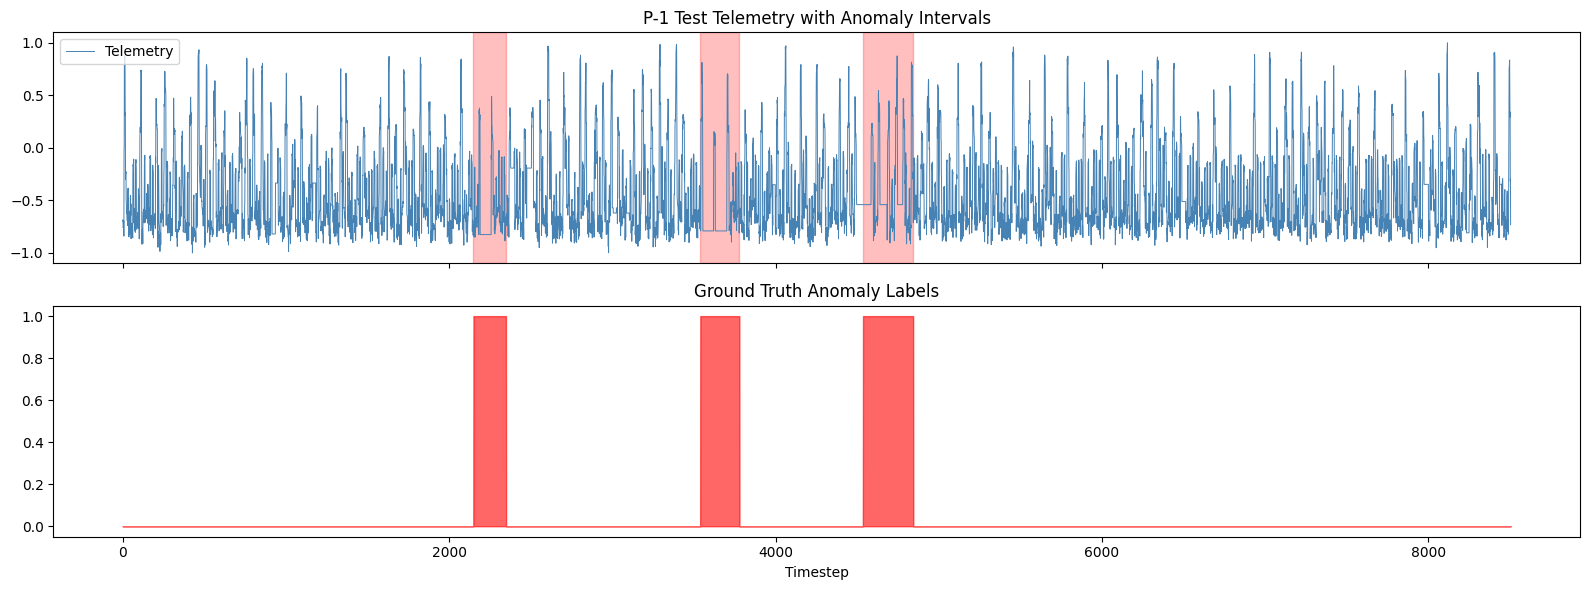

In [50]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2,1, figsize=(16,6), sharex=True)

# Panel 1 — telemetry signal
ax[0].plot(test[:,0], color="steelblue", lw=0.7, label="Telemetry")

for start, end in intervals:
    ax[0].axvspan(start, end, color="red", alpha=0.25)

ax[0].set_title("P-1 Test Telemetry with Anomaly Intervals")
ax[0].legend()


# Panel 2 — anomaly label mask
ax[1].fill_between(range(len(y_true)), y_true, color="red", alpha=0.6)

ax[1].set_title("Ground Truth Anomaly Labels")
ax[1].set_xlabel("Timestep")

plt.tight_layout()

plt.savefig("results/plots/P1_data_check.png", dpi=150)

plt.show()